In [1]:
import ast
import concurrent.futures
import glob
import itertools
import os
import pickle
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

import dask
import dask.dataframe as dd
import dask_ml.cluster as dask_cluster
from dask.distributed import Client
from dask.diagnostics import ProgressBar

from concurrent.futures import ThreadPoolExecutor
from joblib import Parallel, delayed
from multiprocessing import Pool, cpu_count

from sklearn.linear_model import LinearRegression
from sklearn.metrics import pairwise_distances, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score
#from sklearn.cluster import KMeans

from statsmodels.regression.rolling import RollingOLS

from tqdm.notebook import tqdm
from collections import Counter
from functools import reduce
from pprint import pprint

pd.set_option('display.max_columns', None)

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
feature_importance_df = pd.read_csv("time_variant_feature_importance.csv")

In [3]:
#exclusion_cols = ["fips", "log_rolled_cases.y", "cutoff", "t0.lm", "r.lm"]
filtered_feature_importance_df = feature_importance_df
normalized_filtered_feature_importance_df = filtered_feature_importance_df.div(filtered_feature_importance_df.sum(axis=1), axis=0)
normalized_filtered_feature_importance_df

,cases,deaths,rolled_cases,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,State_FIPS_Code,State_of_emergency_issued,State_of_emergency_lifted,Date_closed_K-12_public_schools,Closed_day_cares,Reopen_day_cares,Date_banned_visitors_to_nursing_homes,Stay_at_home/_shelter_in_place,Stay_at_home_order'_issued_but_did_not_specifically_restrict_movement_of_the_general_public,End/relax_stay_at_home/shelter_in_place,Closed_other_non-essential_businesses,Closed_businesses_overnight,Began_to_reopen_businesses,Religious_gatherings_exempt_without_clear_social_distance_mandate*,Face_mask_mandate_in_public_spaces,Face_mask_mandate_x2,Face_mask_mandate_enforced_by_fines,Face_mask_mandate_enforced_by_criminal_charge/citation,No_legal_enforcement_of_face_mask_mandate,Face_mask_mandate_for_employees_of_public-facing_businesses,Ended_face_mask_mandate,Ended_face_mask_mandate_x2,Attempted_to_prevent_local_governments_from_implementing_face_mask_orders,Banned_local_mask_mandates,Liquor_stores_remained_open,Allowed_restaurants_to_sell_takeout_alcohol,Allowed_restaurants_to_deliver_alcohol,Firearm_sellers_remained_open,Cannabis_dispensaries_considered_essential_business,Closed_restaurants_except_take_out,Reopen_restaurants,Initially_reopen_restaurants_for_outdoor_dining_only,Closed_gyms,Reopened_gyms,Closed_movie_theaters,Reopened_movie_theaters,Closed_Bars,Reopen_bars,Reopened_hair_salons/barber_shops,Reopened_religious_gatherings,Reopened_other_non-essential_retail,Allowed_businesses_to_reopen_overnight,Began_to_reclose_bars,Closed_bars_(x2),Closed_movie_theaters_(x2),Closed_hair_salons/barber_shops_(x2),Closed_gyms_(x2),Closed_restaurants_(x2),Reopened_restaurants_(x2),Reopened_bars_(x2),Reopened_gyms_(x2),Reopened_hair_salons/barber_shops_(x2),Reopened_movie_theaters_(x2),Closed_bars_(x3),Closed_restaurants_(x3),Reopened_bars_(x3),Reopened_restaurants_(x3),Mandate_quarantine_for_those_entering_the_state_from_specific_settings,Mandate_quarantine_for_all_individuals_entering_the_state,Date_all_mandated_quarantines_ended,Date_vaccine_allocation_plan_last_updated,Vaccine_allocation_phase:_Frontline_Healthcare_Workers,Vaccine_allocation_phase:_Healthcare_Service_Workers,Vaccine_allocation_phase:_Home_Healthcare_Workers,Vaccine_allocation_phase:_Additional_Healthcare_Workers,Vaccine_allocation_phase:_Long-term_Care_Residents,Vaccine_allocation_phase:_EMS_Providers,Vaccine_allocation_phase:_Firefighters,Vaccine_allocation_phase:_Law_Enforcement_&_Public_Safety_Personnel,Vaccine_allocation_phase:_Correctional_Staff,Vaccine_allocation_phase:_People_who_are_Incarcerated,Vaccine_allocation_phase:_Residents_of_Homeless_Shelters,Vaccine_allocation_phase:_Adults_Ages_75+,Vaccine_allocation_phase:_Adults_Ages_65+,Vaccine_allocation_phase:_Adults_w/_High-Risk_Medical_Conditions,Vaccine_allocation_phase:_Pre-K-12_School_Employees,Vaccine_allocation_phase:_Higher_Education_Employees,Vaccine_allocation_phase:_Public_Transit_Workers,Vaccine_allocation_phase:_Food_Supply_Workers,Vaccine_allocation_phase:_Grocery_Store_Workers,Vaccine_allocation_phase:_Frontline_Essential_Workers,Vaccine_allocation_phase:_Additional_Essential_

In [4]:
sorted_feature_importance = pd.DataFrame((normalized_filtered_feature_importance_df.sum(axis=0)/normalized_filtered_feature_importance_df.shape[0]).sort_values(ascending=False))
sorted_feature_importance = sorted_feature_importance.rename(columns={0:"Importance (%)"})
sorted_feature_importance = sorted_feature_importance*100

In [5]:
sorted_feature_importance.head(10).sum(), sorted_feature_importance.head(20).sum()

(Importance (%)    48.276163
 dtype: float64,
 Importance (%)    59.532309
 dtype: float64)

No handles with labels found to put in legend.


<Figure size 640x480 with 0 Axes>

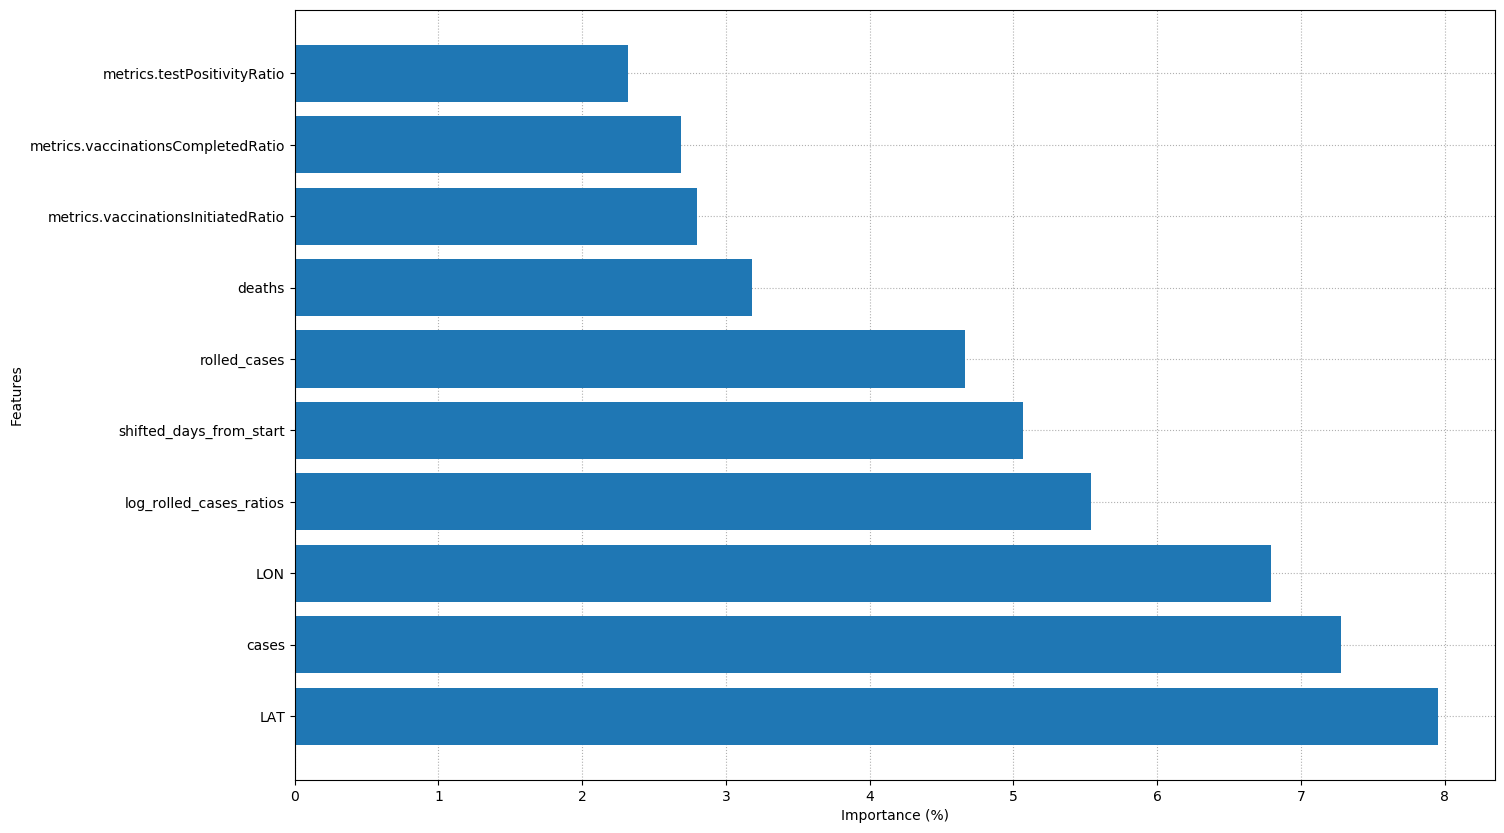

In [6]:
plt.clf()
plt.figure(figsize=(30,10))

to_plot = sorted_feature_importance.head(10)
#to_plot.index = new_names_top_10
plt.barh(to_plot.index,to_plot["Importance (%)"], zorder=2)
plt.ylabel("Features")
plt.xlabel("Importance (%)")
plt.legend().set_visible(False)
plt.grid(True,linestyle='dotted',zorder=1)

plt.gcf().subplots_adjust(left=0.5)

plt.savefig("Time_Varying_Top_10_Feature_Importance.png")

plt.show()

No handles with labels found to put in legend.


<Figure size 640x480 with 0 Axes>

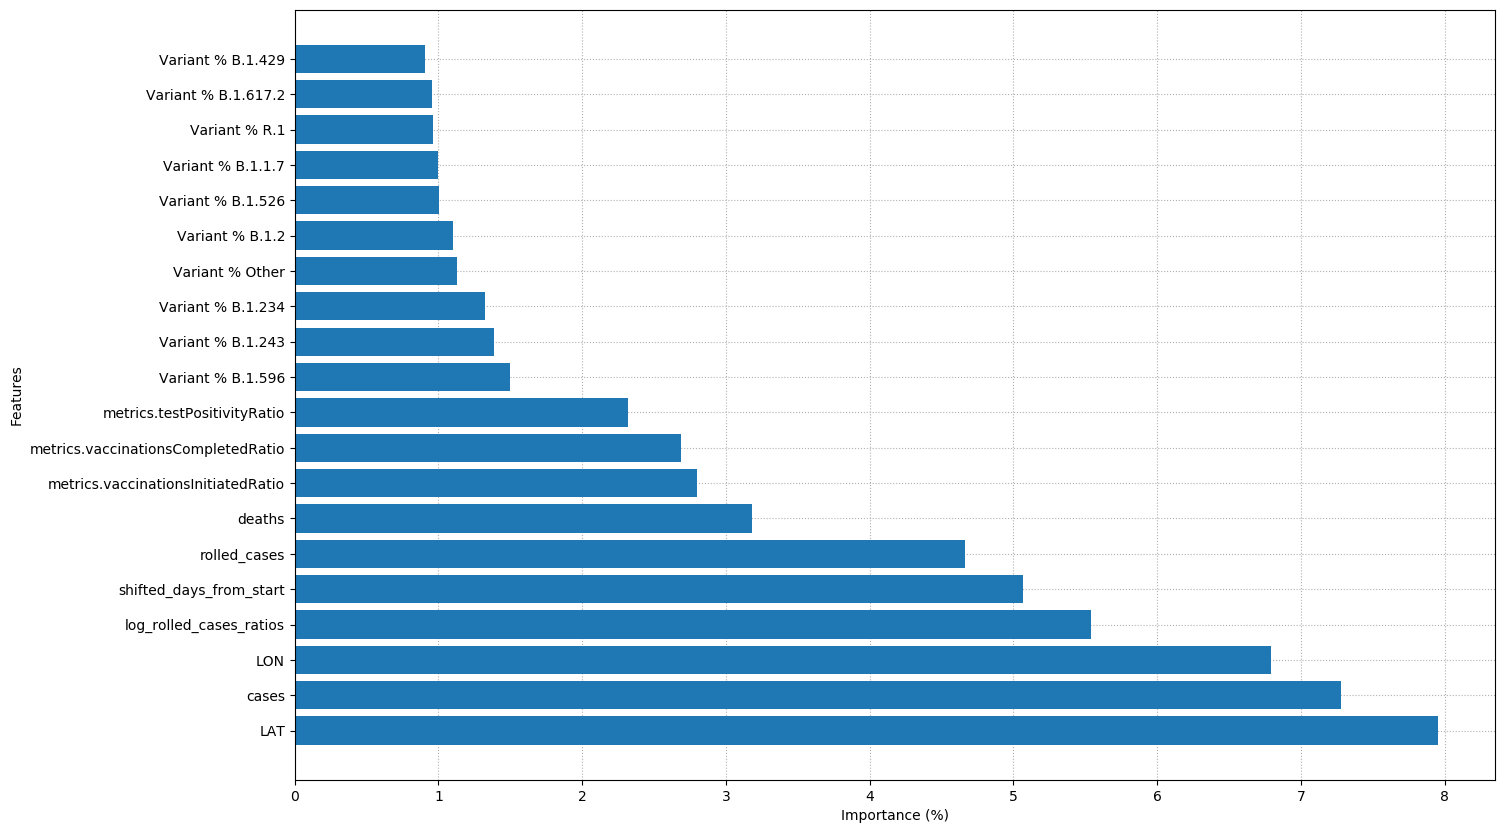

In [7]:
plt.clf()
plt.figure(figsize=(30,10))

to_plot = sorted_feature_importance.head(20)
#to_plot.index = new_names_top_10
plt.barh(to_plot.index,to_plot["Importance (%)"], zorder=2)
plt.ylabel("Features")
plt.xlabel("Importance (%)")
plt.legend().set_visible(False)
plt.grid(True,linestyle='dotted',zorder=1)

plt.gcf().subplots_adjust(left=0.5)

plt.savefig("Time_Varying_Top_20_Feature_Importance.png")

plt.show()